# PERSIAPAN LABORATORIUM
##### ============================================================================
### DOKTRIN: Functional Data Pipeline
- Semua impor dilakukan di sini, sekali jalan.
- Tidak ada state tersembunyi. Semua fungsi murni.
- Penamaan eksplisit, hindari huruf tunggal.
##### ============================================================================

In [7]:
import sys
import os 
from pathlib import Path

#### Menentukan akar proyek secara otomatis (idempotent)
#### Root adalah direktori yang berisi folder 'core' dan 'research'.

In [8]:
try:
    current_path = Path.cwd()
    if current_path.name == 'notebook' and current_path.parent.name == 'research':
        project_root = current_path.parent.parent
    else:
        project_root = current_path

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    print(f" Project root terdeteksi: {project_root}")

except Exception as e:
    print(f" Gagal mendeteksi root. periksa struktur directory/folder/. Error: {e}")


 Project root terdeteksi: /home/bumip/orca


##### ============================================================================
### PUSTAKA ANALITIK (semua diimpor dengan nama eksplisit)
##### ============================================================================

In [88]:
import os 
import sys
import time
from datetime import datetime

# Third-party Lib (Data & Viz)
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import pandas as pd
"""
Local/Custom Core Engine (Black-box Layer)
Memastikan root project masuk ke sys.path jika dijalankan dari sub-folder
"""
sys.path.append(os.path.abspath(os.path.join('..')))

try:
    from core.signals.types import MarketObservation, SignalConfig
    from core.signals.strategies.kalman_mr import KalmanMeanReversion
    from core.math.kalman import KalmanConfig, AdaptationMode
    CORE_LOADED = True

except ImportError as e:
    CORE_LOADED = False
    print(f"Warning: Core component failed to load: {e}")

# Agar tidak ada warning menggangu saat experiment
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f"🚀 Environment Initialized at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


🚀 Environment Initialized at: 2026-03-02 11:05:19


In [77]:
# ============================================================================
# RESEARCH & LAB VISUAL CONFIGURATION
# ============================================================================
def apply_lab_style():
    """ Mengatur estetika plot untuk kebutuhan publikasi/riset quant."""
    sns.set_theme(style="darkgrid", palette="muted")

    custom_params={
        'figure.figsize': (14, 7),
        'figure.dpi': 120,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 13,
        'lines.linewidth': 1.8,
        'legend.frameon': True,
        'savefig.bbox': 'tight',
        'savefig.dpi': 300  # High res untuk simpan gambar
    }

apply_lab_style()

In [78]:
# ============================================================================
# SYSTEM AUDIT (Explicit Version Check)
# ============================================================================
libraries = {
    "polars":  pl.__version__,
    "NumPy": np.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Python": sys.version.split()[0]
}
print("Lab Ready, Lib Audit:")
print("-" * 30)
for lib, version in libraries.items():
    print(f"{lib:<12} : v{version}")
print("-" * 30)
print(f"Core Engine Status: {'Loaded' if CORE_LOADED else 'Failed'}")

Lab Ready, Lib Audit:
------------------------------
polars       : v1.38.1
NumPy        : v2.4.2
Matplotlib   : v3.10.8
Seaborn      : v0.13.2
Python       : v3.11.14
------------------------------
Core Engine Status: Loaded


In [79]:
# ============================================================================
# RESEARCH & LAB VISUAL CONFIGURATION
# ============================================================================
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['savefig.dpi'] = 120

# ============================================================================
# Verifikasi versi
# ============================================================================
print("\n Lab Ready. Versi pustaka/Lib:")
print(f" Polars      :{pl.__version__}")
print(f" NumPy       :{np.__version__}")
print(f" Matplotlib  :{plt.matplotlib.__version__}")
print(f" Seaborn     :{sns.__version__}")


 Lab Ready. Versi pustaka/Lib:
 Polars      :1.38.1
 NumPy       :2.4.2
 Matplotlib  :3.10.8
 Seaborn     :0.13.2


✅ Data dimuat: 44640 baris, kolom: ['timestamp', 'close_DOGE', 'close_BTC']
   Spread dihitung, 44640 baris tersisa setelah drop nulls.

📊 Statistik deskriptif spread:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 44640.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ -13.173351 │
│ std        ┆ 0.048803   │
│ min        ┆ -13.316106 │
│ 25%        ┆ -13.191942 │
│ 50%        ┆ -13.177625 │
│ 75%        ┆ -13.148982 │
│ max        ┆ -13.043397 │
└────────────┴────────────┘


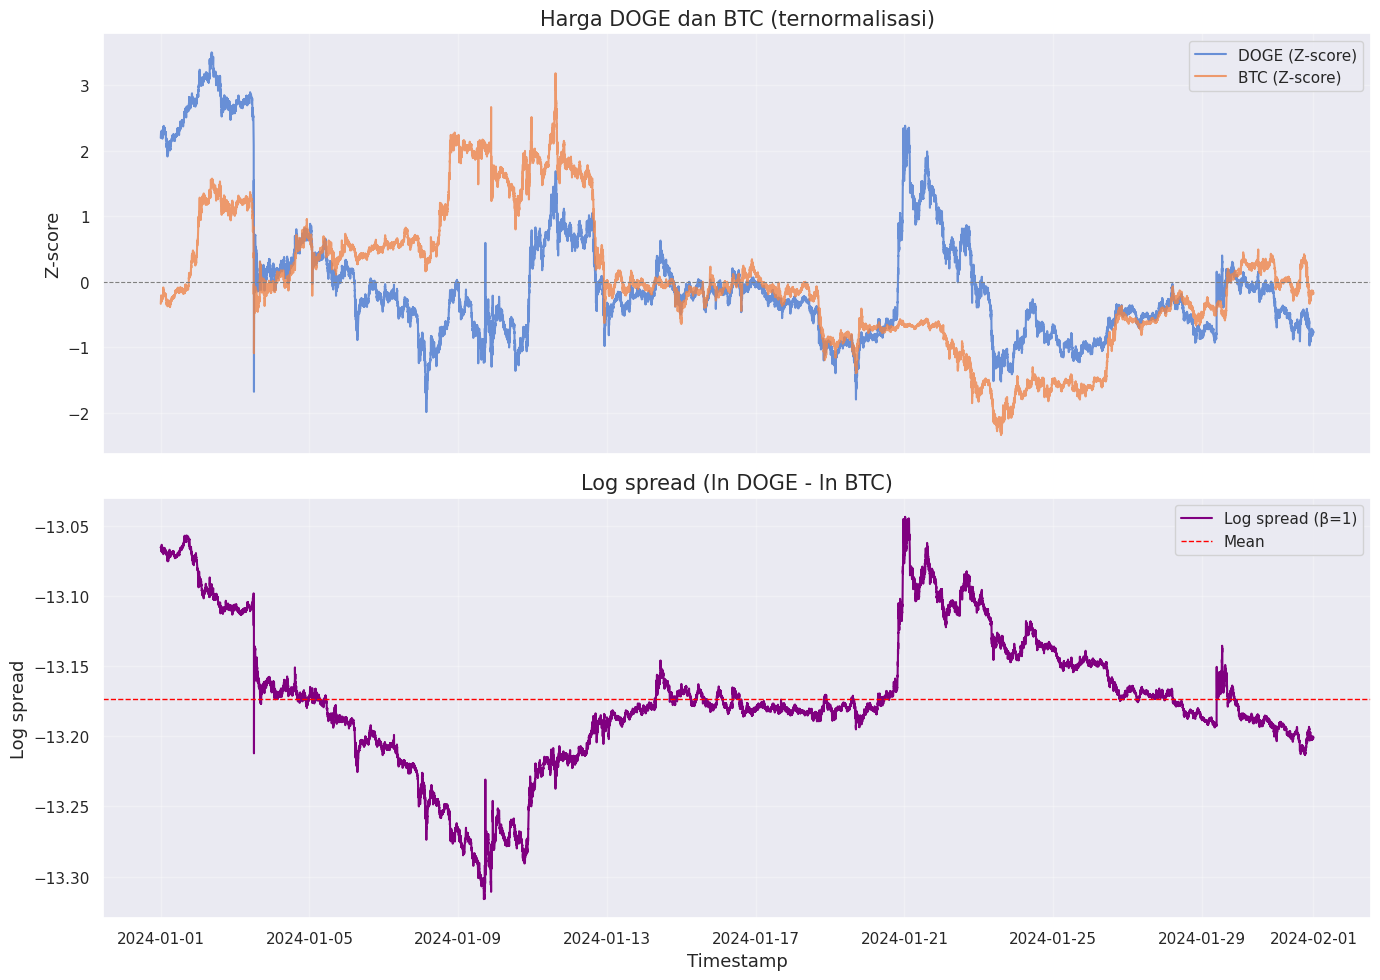


📈 Hasil Uji ADF:
   ADF Statistic     : -2.292319
   p‑value           : 0.174457
   Lag yang digunakan: 55
   Jumlah observasi  : 44584
   ❌ Kesimpulan: Gagal tolak H0. Spread tidak stasioner.
      Mungkin perlu hedge ratio berbeda atau transformasi lain.


In [80]:
# CELL 2: INGESTI DATA & UJI STASIONERITAS
# ============================================================================
# Memuat sampel data Silver Lake (Januari 2024) dan menguji sifat mean-reversion
# spread log dengan ADF test.
# Hipotesis: Data sudah bersih, spread dengan beta=1.0 bersifat stasioner.
# ============================================================================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# ----------------------------------------------------------------------------
# 1. Tentukan jalur data Silver (pastikan path sesuai sistem Anda)
# ----------------------------------------------------------------------------
silver_path = "/home/bumip/orca/data/silver/"

# ----------------------------------------------------------------------------
# 2. Muat data secara lazy dengan partisi Hive (tahun 2024, bulan 01)
# ----------------------------------------------------------------------------
data_lazy = (
    pl.scan_parquet(silver_path + "**/*.parquet", hive_partitioning=True)
    .filter(
        (pl.col("year") == "2024") & 
        (pl.col("month") == "01")
    )
    .select([
        "timestamp",
        "close_DOGE",
        "close_BTC"
    ])
)

# ----------------------------------------------------------------------------
# 3. Kumpulkan data ke memori (masih kecil, sebulan)
# ----------------------------------------------------------------------------
data_raw = data_lazy.collect()
print(f"✅ Data dimuat: {data_raw.shape[0]} baris, kolom: {data_raw.columns}")

# ----------------------------------------------------------------------------
# 4. Hitung log spread (beta = 1.0)
# ----------------------------------------------------------------------------
data_spread = data_raw.with_columns(
    (pl.col("close_DOGE").log() - pl.col("close_BTC").log()).alias("spread_log")
).drop_nulls()  # amankan jika ada null

print(f"   Spread dihitung, {data_spread.shape[0]} baris tersisa setelah drop nulls.")

# ----------------------------------------------------------------------------
# 5. Statistik deskriptif singkat
# ----------------------------------------------------------------------------
print("\n📊 Statistik deskriptif spread:")
print(data_spread["spread_log"].describe())

# ----------------------------------------------------------------------------
# 6. Visualisasi dua panel
# ----------------------------------------------------------------------------
# Normalisasi harga untuk perbandingan visual (Z‑score)
harga_normalized = data_spread.with_columns([
    ((pl.col("close_DOGE") - pl.col("close_DOGE").mean()) / pl.col("close_DOGE").std()).alias("doge_z"),
    ((pl.col("close_BTC") - pl.col("close_BTC").mean()) / pl.col("close_BTC").std()).alias("btc_z")
])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel atas: harga ternormalisasi
ax1.plot(harga_normalized["timestamp"], harga_normalized["doge_z"], 
         label="DOGE (Z‑score)", alpha=0.8, linewidth=1.5)
ax1.plot(harga_normalized["timestamp"], harga_normalized["btc_z"], 
         label="BTC (Z‑score)", alpha=0.8, linewidth=1.5)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_ylabel("Z‑score")
ax1.set_title("Harga DOGE dan BTC (ternormalisasi)")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Panel bawah: log spread
ax2.plot(data_spread["timestamp"], data_spread["spread_log"], 
         color="purple", linewidth=1.5, label="Log spread (β=1)")
ax2.axhline(y=data_spread["spread_log"].mean(), color='red', 
            linestyle='--', linewidth=1, label="Mean")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Log spread")
ax2.set_title("Log spread (ln DOGE - ln BTC)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

if not os.path.exists('plot_result'):
    os.makedirs('plot_result')
plt.tight_layout()
plt.savefig('/home/bumip/orca/research/notebook/plot_result/adf_test', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

# ----------------------------------------------------------------------------
# 7. Uji Augmented Dickey‑Fuller
# ----------------------------------------------------------------------------
spread_array = data_spread["spread_log"].to_numpy()
adf_result = adfuller(spread_array, autolag='AIC')

print("\n📈 Hasil Uji ADF:")
print(f"   ADF Statistic     : {adf_result[0]:.6f}")
print(f"   p‑value           : {adf_result[1]:.6f}")
print(f"   Lag yang digunakan: {adf_result[2]}")
print(f"   Jumlah observasi  : {adf_result[3]}")

# Interpretasi
if adf_result[1] < 0.05:
    print("   ✅ Kesimpulan: Tolak H0. Spread stasioner (mean‑reverting).")
    print("      Kalman Filter diperkirakan efektif.")
else:
    print("   ❌ Kesimpulan: Gagal tolak H0. Spread tidak stasioner.")
    print("      Mungkin perlu hedge ratio berbeda atau transformasi lain.")

# Simpan data spread untuk selanjutnya (tanpa mengubah data asli)
data_spread_clean = data_spread

In [81]:
data_spread_clean.write_csv("doge_btc_adf_020326.csv") 

# ESTIMASI VARIANS EMPIRIS – THE R ANCHOR
##### ============================================================================
- Menghitung rolling variance dari log spread untuk mendapatkan baseline
- Observation noices (R) bagi kalman Filter.
- Metodologi: rolling window → median sebagai anchor, persentil 5 dan 95
- sebagai batas wajar.
##### ============================================================================

In [115]:
"""
- Parameter jendela waktu (data disesuikan) 
- hitung rolling variance (variance berjalan) -- IDEMPOTEN 
"""
rolling_window = 60 // 2 #asusmiskan data per-menit * 60 * jam = rolling window dalam jam

# gunakan data dari operasi sebelumnya ( data spread clean )
data_variance = data_spread_clean.with_columns(
    pl.col("spread_log")
    .rolling_var(window_size=rolling_window)
    .alias("variance_rolling")
).drop_nulls(subset=["variance_rolling"])

print(f"Rolling variance dihitung dengan window {rolling_window}")
print(f"Jumlah data setelah drop nulls: {data_variance.shape[0]} baris")


Rolling variance dihitung dengan window 30
Jumlah data setelah drop nulls: 44611 baris


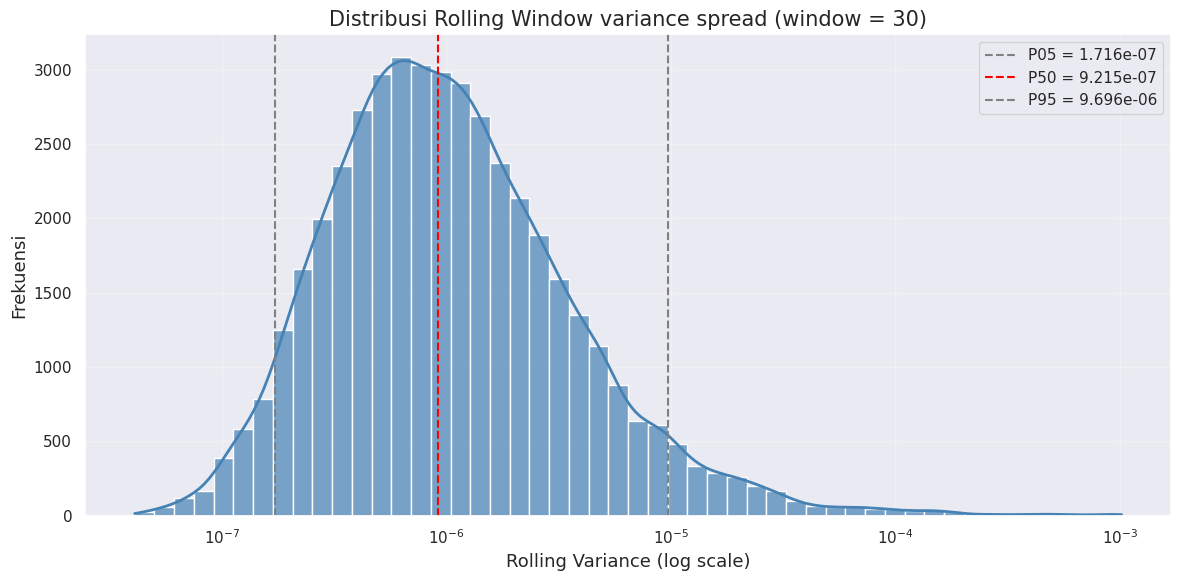

In [116]:
"""
- Ekstrak array variance dan hitung persentil
- Visualisasi histogram dengan skala log
"""
variance_array = data_variance["variance_rolling"].to_numpy()

variance_p05 = np.percentile(variance_array, 5)
variance_p50 = np.percentile(variance_array, 50)    # Mean atau Anchor R
variance_p95 = np.percentile(variance_array, 95)

fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(variance_array, bins=50, kde=True, log_scale=True, ax=ax,
            color='steelblue', alpha=0.7)
# Garis vertikal untuk persentil
ax.axvline(variance_p05, color='gray', linestyle='--', linewidth=1.5,
          label=f"P05 = {variance_p05:.3e}")
ax.axvline(variance_p50, color='red', linestyle='--', linewidth=1.5,
          label=f"P50 = {variance_p50:.3e}")
ax.axvline(variance_p95, color='gray', linestyle='--', linewidth=1.5,
          label=f"P95 = {variance_p95:.3e}")

ax.set_xlabel("Rolling Variance (log scale)")
ax.set_ylabel("Frekuensi")
ax.set_title(f"Distribusi Rolling Window variance spread (window = {rolling_window})")
ax.legend()
ax.grid(True, alpha=0.3)

if not os.path.exists('plot_result'):
    os.makedirs('plot_result')
plt.tight_layout()
plt.savefig('/home/bumip/orca/research/notebook/plot_result/distr_rwvs_win30', dpi=300, bbox_inches='tight')
plt.show()

# UJI TRANSLASI AGNOSTIK – THE BRIDGE VALIDATION
##### ============================================================================
- Memastikan data tabular dapat dikonsumsi oleh mesin kalman tanpa crash -- kalman_mr ada di core/signals/strategies
- Menggunakan 500 baris pertama, dikemas sebagai class MarketObservation.
- Menangkap keluaran Z-score untuk memverfikasi bawa filter aktif
##### ============================================================================

In [189]:
"""
- Ambil parameter R dari hasil Cell 3 (median variance) dan tetapkan Q
- Konfigurasi sinyal dan matematika (eksplisit, panjang nama)
- Rakit mesin Kalman (black box)
"""
# Pastikan variabel variance_p50 sudah ada (hasil Cell 3)
try:
    r_anchor = variance_p50
except NameError:
    r_anchor = 1e-6
    print(f"Variance percentile 50 (mean) tidak ditemukan, default fallback R = {r_anchor:.e3}")

# Process noise harus jauh lebih kecil dari observation noise
q_process = 1e-12
print(f" Menggunakan R = {r_anchor:.3e}, Q = {q_process:.3e}")

konfigurasi_sinyal_lab = SignalConfig(
    name="Lab_Test_Brigde",
    entry_z_score=2.0,
    exit_z_score=1.0,
    stop_loss_z=4.0,
    max_position=1.0,
    hedge_ratio=1.0,
    volatility_window=rolling_window
)

konfigurasi_math_lab = KalmanConfig(
    R=r_anchor,
    Q=q_process,
    initial_value=0.0,
    adaptation_mode=AdaptationMode.NIS_THRESHOLD,
    state_dim=2
)

mesin_kalman_lab = KalmanMeanReversion(
    signal_config=konfigurasi_sinyal_lab,
    math_config=konfigurasi_math_lab
)
print(" Mesin Kalman Ready")

 Menggunakan R = 9.215e-07, Q = 1.000e-12
 Mesin Kalman Ready


In [190]:
"""
- Ambil sampel 500 baris pertama dari data mentah (Cell atas)
- Loop data dan record Z-Score
"""
# Gunakan data_raw yang sudah di muat di cell atas 
try:
    sampel_data_500 = data_raw.head(500)
except NameError:
    raise NameError("data_raw tidak ditemukan. Jalankan Cell 2 terlebih dahulu.")

# Konversi timestamp ke milidetik integer (Polars timestamp biasanya dalam nanodetik)
sampel_data_500 = sampel_data_500.with_columns(
    pl.col("timestamp").cast(pl.Int64) // 1_000_000
)
print(f"📦 Sampel data: {sampel_data_500.shape[0]} baris, kolom: {sampel_data_500.columns}")

daftar_kamus_data = sample_data_500.to_dicts()
print(f"Sample data: {len(daftar_kamus_data)} baris (dicts)")

start_time = time.time()
hasil_batch = mesin_kalman_lab.generate_signals(sampel_data_500.to_pandas())
durasi = (time.time() - start_time) * 1000  # milidetik

if hasil_batch.is_ok():
    df_hasil = hasil_batch.unwrap()
    print(f"✅ Batch processing selesai dalam {durasi:.2f} ms.")
    print(f"   Baris hasil: {len(df_hasil)}")
    print(f"   Kolom baru: {[c for c in df_hasil.columns if c not in sampel_data_500.columns]}")
    
    # Ambil sinyal dan z-score
    contoh_sinyal = df_hasil[['timestamp', 'signal_type', 'signal_strength', 'z_score']].head(10)
    print("\n📊 Contoh 10 baris pertama sinyal:")
    print(contoh_sinyal)
    
    # Periksa warmup: 100 baris pertama harus NEUTRAL / z_score 0
    warmup_sinyal = df_hasil['signal_type'].iloc[:100].value_counts()
    print("\n🔥 Distribusi sinyal selama 100 baris pertama (warmup):")
    print(warmup_sinyal)
    
    # Periksa akhir: harus ada sinyal non-NEUTRAL
    akhir_sinyal = df_hasil['signal_type'].iloc[-100:].value_counts()
    print("\n📈 Distribusi sinyal 100 baris terakhir:")
    print(akhir_sinyal)
    
    if 'NEUTRAL' in warmup_sinyal.index and warmup_sinyal['NEUTRAL'] == 100:
        print("✅ Warmup berfungsi: 100 baris pertama semuanya NEUTRAL.")
    else:
        print("⚠️  Warmup tidak sempurna – mungkin window berbeda.")
    
    if any(t != 'NEUTRAL' for t in df_hasil['signal_type'].iloc[-100:]):
        print("✅ Sinyal aktif muncul di akhir – filter bernapas.")
    else:
        print("⚠️  Tidak ada sinyal aktif – periksa parameter.")
    
else:
    print(f"❌ Batch processing gagal: {hasil_batch.unwrap_err()}")
    df_hasil = None



📦 Sampel data: 500 baris, kolom: ['timestamp', 'close_DOGE', 'close_BTC']
Sample data: 500 baris (dicts)
✅ Batch processing selesai dalam 233.63 ms.
   Baris hasil: 500
   Kolom baru: ['signal_type', 'signal_type_name', 'signal_strength', 'signal_metadata', 'z_score', 'spread_val', 'estimate']

📊 Contoh 10 baris pertama sinyal:
   timestamp signal_type  signal_strength  z_score
0    1704067     NEUTRAL              0.0      0.0
1    1704067     NEUTRAL              0.0      0.0
2    1704067     NEUTRAL              0.0      0.0
3    1704067     NEUTRAL              0.0      0.0
4    1704067     NEUTRAL              0.0      0.0
5    1704067     NEUTRAL              0.0      0.0
6    1704067     NEUTRAL              0.0      0.0
7    1704067     NEUTRAL              0.0      0.0
8    1704067     NEUTRAL              0.0      0.0
9    1704067     NEUTRAL              0.0      0.0

🔥 Distribusi sinyal selama 100 baris pertama (warmup):
signal_type
NEUTRAL    100
Name: count, dtype: int64


In [191]:
print("\n" + "="*60)
print("📊 [DIAGNOSTIK JEMBATAN DATA - CELL 4]")
print("="*60)
print(f"   Total Baris Diproses : {len(sampel_data_500)}")
print(f"   Durasi Pemrosesan    : {durasi:.2f} ms")
if df_hasil is not None:
    print(f"   Jumlah Sinyal BUY    : {(df_hasil['signal_type'] == 'BUY').sum()}")
    print(f"   Jumlah Sinyal SELL   : {(df_hasil['signal_type'] == 'SELL').sum()}")
    print(f"   Jumlah Sinyal EXIT   : {(df_hasil['signal_type'] == 'EXIT').sum()}")
    print(f"   Jumlah Sinyal STOP   : {(df_hasil['signal_type'] == 'STOP').sum()}")
    print(f"   Rata-rata Z-Score    : {df_hasil['z_score'].mean():.4f}")
print("="*60)


📊 [DIAGNOSTIK JEMBATAN DATA - CELL 4]
   Total Baris Diproses : 500
   Durasi Pemrosesan    : 233.63 ms
   Jumlah Sinyal BUY    : 1
   Jumlah Sinyal SELL   : 0
   Jumlah Sinyal EXIT   : 0
   Jumlah Sinyal STOP   : 0
   Rata-rata Z-Score    : -1.3439


Kolom di df_plot (hasil batch processing): ['timestamp', 'close_DOGE', 'close_BTC', 'signal_type', 'signal_type_name', 'signal_strength', 'signal_metadata', 'z_score', 'spread_val', 'estimate', 'datetime']
✅ Kolom harga tersedia, akan ditampilkan di panel atas.


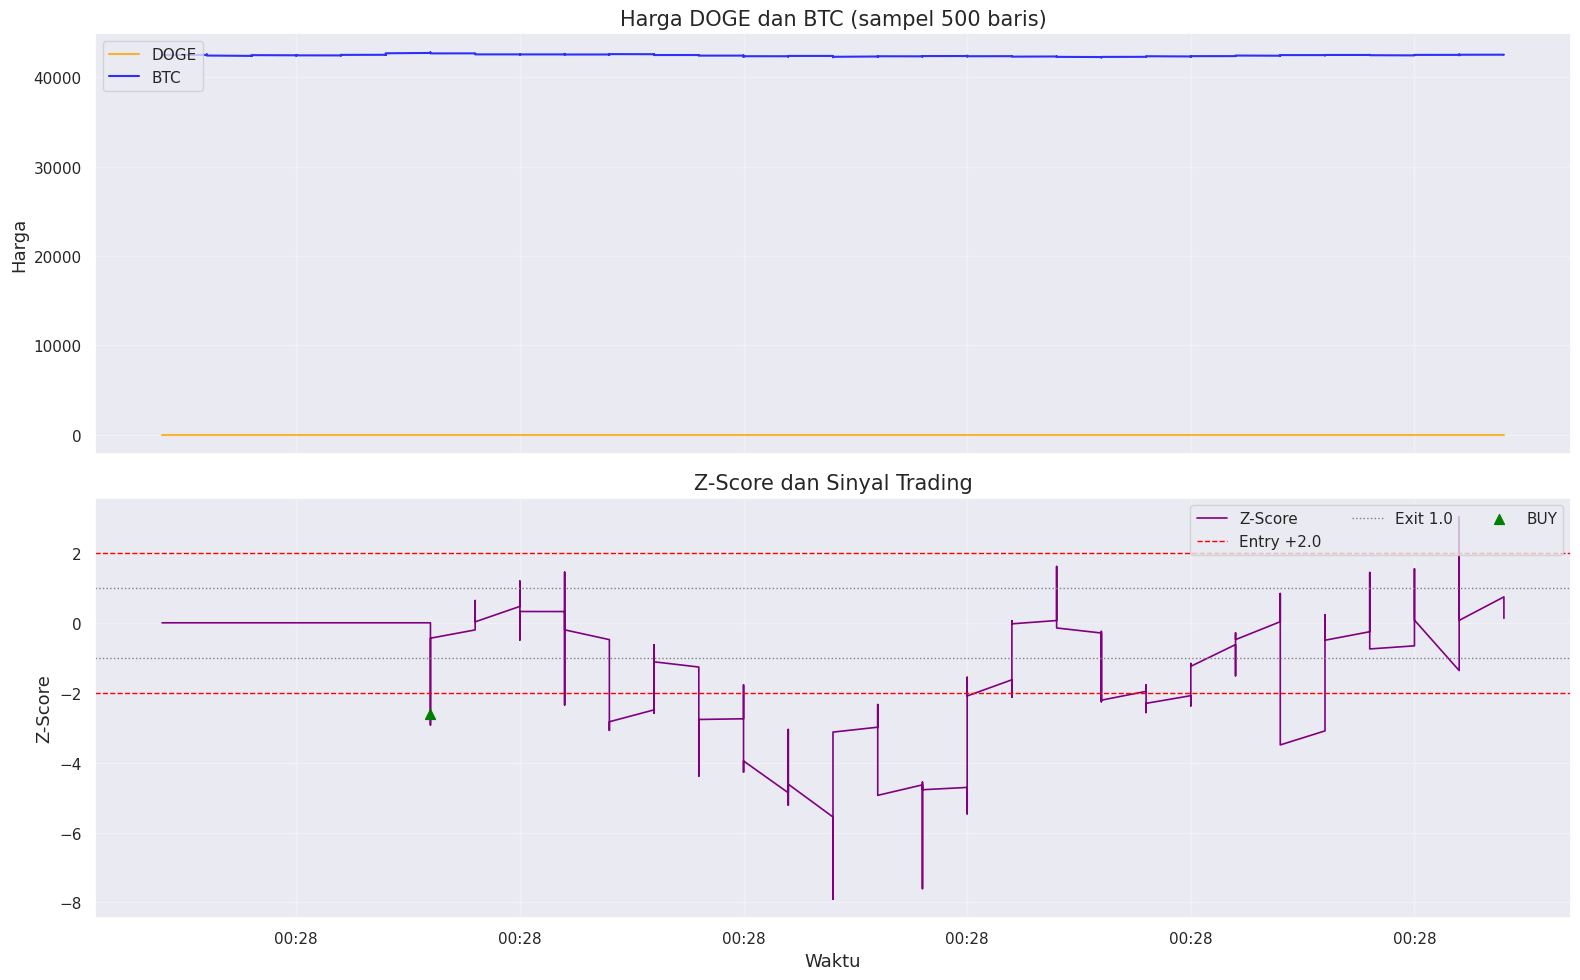


📈 Ringkasan sinyal:
signal_type
NEUTRAL    499
BUY          1
Name: count, dtype: int64
   Rata-rata Z-Score (setelah warmup): -1.6799


In [192]:
# CELL 4 (lanjutan): VISUALISASI HASIL BATCH PROCESSING (Revisi)
# ============================================================================
# Menampilkan Z-Score dan sinyal trading dari batch processing.
# Data harga sudah tersedia di df_hasil (dari generate_signals), 
# sehingga tidak perlu merge ulang.
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Pastikan df_hasil dari batch processing tersedia
if df_hasil is not None:
    # ------------------------------------------------------------------------
    # 1. Siapkan dataframe untuk plotting (langsung dari df_hasil)
    # ------------------------------------------------------------------------
    df_plot = df_hasil.copy()
    df_plot['datetime'] = pd.to_datetime(df_plot['timestamp'], unit='ms')
    
    # Debug: cetak kolom yang tersedia
    print("Kolom di df_plot (hasil batch processing):", df_plot.columns.tolist())
    
    # ------------------------------------------------------------------------
    # 2. Periksa keberadaan kolom harga yang diperlukan
    # ------------------------------------------------------------------------
    # Dalam implementasi kalman_mr.py, generate_signals mengembalikan 
    # dataframe asli + kolom sinyal, jadi seharusnya 'close_DOGE' dan 'close_BTC' ada.
    required_price_cols = ['close_DOGE', 'close_BTC']
    missing_cols = [col for col in required_price_cols if col not in df_plot.columns]
    
    if missing_cols:
        print(f"⚠️ Kolom harga berikut TIDAK ditemukan di df_plot: {missing_cols}")
        print("   → Plot hanya akan menampilkan Z-Score (tanpa harga).")
        plot_harga = False
    else:
        plot_harga = True
        print("✅ Kolom harga tersedia, akan ditampilkan di panel atas.")
    
    # ------------------------------------------------------------------------
    # 3. Parameter threshold
    # ------------------------------------------------------------------------
    entry_threshold = konfigurasi_sinyal_lab.entry_z_score
    exit_threshold = konfigurasi_sinyal_lab.exit_z_score
    
    # ------------------------------------------------------------------------
    # 4. Plot berdasarkan ketersediaan harga
    # ------------------------------------------------------------------------
    if not plot_harga:
        # Hanya panel Z-Score
        fig, ax = plt.subplots(figsize=(14, 6))
        
        ax.plot(df_plot['datetime'], df_plot['z_score'],
                color='purple', linewidth=1.2, label='Z-Score')
        
        # Threshold lines
        ax.axhline(y=entry_threshold, color='red', linestyle='--',
                   label=f'Entry +{entry_threshold}')
        ax.axhline(y=-entry_threshold, color='red', linestyle='--')
        ax.axhline(y=exit_threshold, color='gray', linestyle=':',
                   label=f'Exit {exit_threshold}')
        ax.axhline(y=-exit_threshold, color='gray', linestyle=':')
        
        # Marker sinyal
        buy = df_plot[df_plot['signal_type'] == 'BUY']
        sell = df_plot[df_plot['signal_type'] == 'SELL']
        exit_ = df_plot[df_plot['signal_type'] == 'EXIT']
        stop_ = df_plot[df_plot['signal_type'] == 'STOP']
        
        if not buy.empty:
            ax.scatter(buy['datetime'], buy['z_score'],
                       color='green', marker='^', s=50, label='BUY', zorder=5)
        if not sell.empty:
            ax.scatter(sell['datetime'], sell['z_score'],
                       color='red', marker='v', s=50, label='SELL', zorder=5)
        if not exit_.empty:
            ax.scatter(exit_['datetime'], exit_['z_score'],
                       color='blue', marker='o', s=40, label='EXIT', zorder=5)
        if not stop_.empty:
            ax.scatter(stop_['datetime'], stop_['z_score'],
                       color='black', marker='x', s=40, label='STOP', zorder=5)
        
        ax.set_xlabel('Waktu')
        ax.set_ylabel('Z-Score')
        ax.set_title('Z-Score (harga tidak tersedia dalam data)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # Format sumbu waktu
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        
        plt.tight_layout()
        plt.show()
        
    else:
        # Plot dua panel: harga (atas) dan Z-Score (bawah)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
        
        # Panel atas: harga DOGE dan BTC (langsung dari df_plot)
        ax1.plot(df_plot['datetime'], df_plot['close_DOGE'],
                 label='DOGE', color='orange', alpha=0.8, linewidth=1.5)
        ax1.plot(df_plot['datetime'], df_plot['close_BTC'],
                 label='BTC', color='blue', alpha=0.8, linewidth=1.5)
        ax1.set_ylabel('Harga')
        ax1.set_title('Harga DOGE dan BTC (sampel 500 baris)')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # Panel bawah: Z-Score dan sinyal
        ax2.plot(df_plot['datetime'], df_plot['z_score'],
                 color='purple', linewidth=1.2, label='Z-Score')
        
        ax2.axhline(y=entry_threshold, color='red', linestyle='--',
                    linewidth=1, label=f'Entry +{entry_threshold}')
        ax2.axhline(y=-entry_threshold, color='red', linestyle='--', linewidth=1)
        ax2.axhline(y=exit_threshold, color='gray', linestyle=':',
                    linewidth=1, label=f'Exit {exit_threshold}')
        ax2.axhline(y=-exit_threshold, color='gray', linestyle=':', linewidth=1)
        
        # Marker sinyal
        buy = df_plot[df_plot['signal_type'] == 'BUY']
        sell = df_plot[df_plot['signal_type'] == 'SELL']
        exit_ = df_plot[df_plot['signal_type'] == 'EXIT']
        stop_ = df_plot[df_plot['signal_type'] == 'STOP']
        
        if not buy.empty:
            ax2.scatter(buy['datetime'], buy['z_score'],
                        color='green', marker='^', s=50, label='BUY', zorder=5)
        if not sell.empty:
            ax2.scatter(sell['datetime'], sell['z_score'],
                        color='red', marker='v', s=50, label='SELL', zorder=5)
        if not exit_.empty:
            ax2.scatter(exit_['datetime'], exit_['z_score'],
                        color='blue', marker='o', s=40, label='EXIT', zorder=5)
        if not stop_.empty:
            ax2.scatter(stop_['datetime'], stop_['z_score'],
                        color='black', marker='x', s=40, label='STOP', zorder=5)
        
        ax2.set_xlabel('Waktu')
        ax2.set_ylabel('Z-Score')
        ax2.set_title('Z-Score dan Sinyal Trading')
        ax2.legend(loc='upper right', ncol=3)
        ax2.grid(True, alpha=0.3)
        
        # Format sumbu waktu
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
        
        plt.tight_layout()
        plt.show()
    
    # ------------------------------------------------------------------------
    # 5. Ringkasan statistik sinyal
    # ------------------------------------------------------------------------
    print("\n📈 Ringkasan sinyal:")
    print(df_plot['signal_type'].value_counts())
    print(f"   Rata-rata Z-Score (setelah warmup): {df_plot['z_score'].iloc[100:].mean():.4f}")
    
else:
    print("❌ Tidak ada data untuk divisualisasikan. Batch processing mungkin gagal.")

# EKSPLORASI SENSITIVITAS Q – VISUAL GRID
##### ============================================================================
#### Menguji tiga kepribadian Kalman Filter dengan nilai Q berbeda:
-  Kaku (Q sangat kecil)  → 1e-12
- Seimbang (Q sedang)    → 1e-10
- Reaktif (Q besar)      → 1e-6
- R tetap menggunakan anchor dari Cell 3.
##### ============================================================================

In [201]:
# ----------------------------------------------------------------------------
# 1. Siapkan data sampel (3000 baris pertama)
# ----------------------------------------------------------------------------
try:
    # Pastikan data_raw dalam format yang benar (timestamp integer ms)
    data_3000 = data_raw.head(3000).with_columns(
        pl.col("timestamp").cast(pl.Int64) // 1_000_000
    )
    print(f"✅ Data sampel: {data_3000.shape[0]} baris (3000 baris pertama).")
except NameError:
    raise NameError("data_raw tidak ditemukan. Jalankan Cell 2 terlebih dahulu.")

# ----------------------------------------------------------------------------
# 2. Parameter tetap (dari sel sebelumnya)
# ----------------------------------------------------------------------------
r_anchor = variance_p50          # dari Cell 3
rolling_window = rolling_window  # dari Cell 3 (60)
entry_z = 2.0
exit_z = 1.0

print(f"🔧 R tetap = {r_anchor:.3e}")
print(f"🔧 Window volatilitas = {rolling_window}")

✅ Data sampel: 3000 baris (3000 baris pertama).
🔧 R tetap = 9.215e-07
🔧 Window volatilitas = 30


In [202]:
# ----------------------------------------------------------------------------
# 1. Siapkan data sampel (3000 baris pertama)
# ----------------------------------------------------------------------------
try:
    # Pastikan data_raw dalam format yang benar (timestamp integer ms)
    data_3000 = data_raw.head(3000).with_columns(
        pl.col("timestamp").cast(pl.Int64) // 1_000_000
    )
    print(f"✅ Data sampel: {data_3000.shape[0]} baris (3000 baris pertama).")
except NameError:
    raise NameError("data_raw tidak ditemukan. Jalankan Cell 2 terlebih dahulu.")

# ----------------------------------------------------------------------------
# 2. Parameter tetap (dari sel sebelumnya)
# ----------------------------------------------------------------------------
r_anchor = variance_p50          # dari Cell 3
rolling_window = rolling_window  # dari Cell 3 (60)
entry_z = 2.0
exit_z = 0.5

print(f"🔧 R tetap = {r_anchor:.3e}")
print(f"🔧 Window volatilitas = {rolling_window}")

✅ Data sampel: 3000 baris (3000 baris pertama).
🔧 R tetap = 9.215e-07
🔧 Window volatilitas = 30


In [203]:
# ----------------------------------------------------------------------------
# 3. Konfigurasi sinyal (sama untuk semua skenario)
# ----------------------------------------------------------------------------
signal_cfg = SignalConfig(
    name="Sensitivitas_Q_Test",
    entry_z_score=entry_z,
    exit_z_score=exit_z,
    stop_loss_z=4.0,
    max_position=1.0,
    hedge_ratio=1.0,
    volatility_window=rolling_window
)

# ----------------------------------------------------------------------------
# 4. Tiga nilai Q yang akan diuji
# ----------------------------------------------------------------------------
q_values = {
    "kaku": 1e-12,
    "seimbang": 1e-10,
    "reaktif": 1e-6
}

# ----------------------------------------------------------------------------
# 5. Fungsi pembantu untuk menjalankan satu skenario (idempoten, pure)
# ----------------------------------------------------------------------------
def jalankan_skenario(nama: str, q: float) -> pd.DataFrame:
    """
    Membuat mesin Kalman dengan Q tertentu, menjalankan batch,
    dan mengembalikan DataFrame hasil.
    """
    print(f"\n🚀 Menjalankan skenario: {nama} (Q = {q:.1e})")
    
    math_cfg = KalmanConfig(
        R=r_anchor,
        Q=q,
        initial_value=0.0,
        adaptation_mode=AdaptationMode.NIS_THRESHOLD,
        state_dim=2
    )
    
    mesin = KalmanMeanReversion(
        signal_config=signal_cfg,
        math_config=math_cfg
    )
    
    start = time.time()
    hasil = mesin.generate_signals(data_3000.to_pandas())
    durasi = (time.time() - start) * 1000
    
    if hasil.is_err():
        raise RuntimeError(f"❌ Gagal pada skenario {nama}: {hasil.unwrap_err()}")
    
    df = hasil.unwrap()
    print(f"   ✅ Selesai dalam {durasi:.2f} ms.")
    return df

In [204]:
# ----------------------------------------------------------------------------
# 6. Jalankan ketiga skenario
# ----------------------------------------------------------------------------
df_kaku = jalankan_skenario("kaku", q_values["kaku"])
df_seimbang = jalankan_skenario("seimbang", q_values["seimbang"])
df_reaktif = jalankan_skenario("reaktif", q_values["reaktif"])

# ----------------------------------------------------------------------------
# 7. Tambahkan kolom datetime untuk sumbu waktu yang rapi
# ----------------------------------------------------------------------------
for df in [df_kaku, df_seimbang, df_reaktif]:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')



🚀 Menjalankan skenario: kaku (Q = 1.0e-12)
   ✅ Selesai dalam 1937.49 ms.

🚀 Menjalankan skenario: seimbang (Q = 1.0e-10)
   ✅ Selesai dalam 1548.94 ms.

🚀 Menjalankan skenario: reaktif (Q = 1.0e-06)
   ✅ Selesai dalam 1529.16 ms.


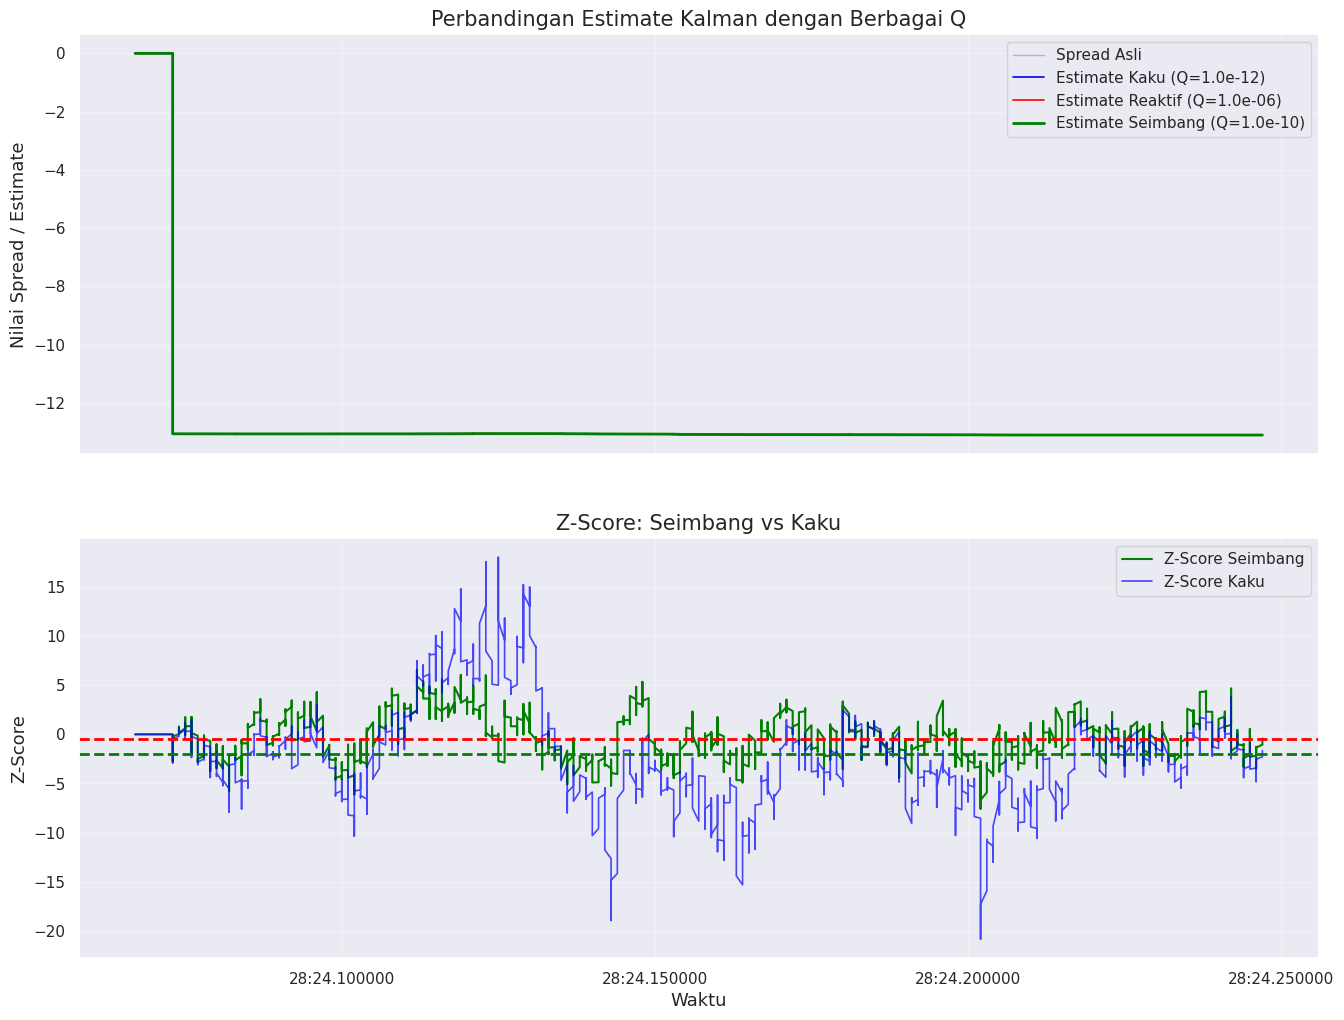

In [207]:

# ----------------------------------------------------------------------------
# 7. Tambahkan kolom datetime untuk sumbu waktu yang rapi
# ----------------------------------------------------------------------------
for df in [df_kaku, df_seimbang, df_reaktif]:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# ----------------------------------------------------------------------------
# 8. Visualisasi dua panel
# ----------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Panel Atas: Spread Asli vs Estimate
ax1.plot(df_seimbang['datetime'], df_seimbang['spread_val'],
         color='gray', alpha=0.5, linewidth=1.0, label='Spread Asli')
ax1.plot(df_kaku['datetime'], df_kaku['estimate'],
         color='blue', linewidth=1.2, label=f'Estimate Kaku (Q={q_values["kaku"]:.1e})')
ax1.plot(df_reaktif['datetime'], df_reaktif['estimate'],
         color='red', linewidth=1.2, label=f'Estimate Reaktif (Q={q_values["reaktif"]:.1e})')
ax1.plot(df_seimbang['datetime'], df_seimbang['estimate'],
         color='green', linewidth=2.0, label=f'Estimate Seimbang (Q={q_values["seimbang"]:.1e})')

ax1.set_ylabel('Nilai Spread / Estimate')
ax1.set_title('Perbandingan Estimate Kalman dengan Berbagai Q')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel Bawah: Z-Score (hanya seimbang dan kaku, reaktif biasanya terlalu kecil)
ax2.plot(df_seimbang['datetime'], df_seimbang['z_score'],
         color='green', linewidth=1.5, label='Z-Score Seimbang')
ax2.plot(df_kaku['datetime'], df_kaku['z_score'],
         color='blue', linewidth=1.2, alpha=0.7, label='Z-Score Kaku')

# Garis threshold
plt.axhline(-0.5, color='red', linestyle='--') # Garis Exit BUY
plt.axhline(-2.0, color='green', linestyle='--') # Garis Entry BUY


ax2.set_xlabel('Waktu')
ax2.set_ylabel('Z-Score')
ax2.set_title('Z-Score: Seimbang vs Kaku')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
plt.show()

In [208]:
# ----------------------------------------------------------------------------
# 9. Statistik ringkasan untuk setiap skenario
# ----------------------------------------------------------------------------
print("\n" + "="*60)
print("📊 [RINGKASAN SENSITIVITAS Q]")
print("="*60)

for nama, df in [("Kaku", df_kaku), ("Seimbang", df_seimbang), ("Reaktif", df_reaktif)]:
    z_after_warmup = df['z_score'].iloc[100:]  # lewati 100 baris warmup
    std_z = z_after_warmup.std()
    n_buy = (df['signal_type'] == 'BUY').sum()
    n_sell = (df['signal_type'] == 'SELL').sum()
    n_exit = (df['signal_type'] == 'EXIT').sum()
    n_stop = (df['signal_type'] == 'STOP').sum()
    
    # Ambil nilai Q yang sesuai (karena nama tidak case-sensitive)
    if nama.lower() == "kaku":
        q_val = q_values["kaku"]
    elif nama.lower() == "seimbang":
        q_val = q_values["seimbang"]
    else:
        q_val = q_values["reaktif"]
    
    print(f"\n🔹 Skenario {nama} (Q = {q_val:.1e})")
    print(f"   Std Dev Z-Score (post-warmup) : {std_z:.4f}")
    print(f"   Jumlah BUY       : {n_buy}")
    print(f"   Jumlah SELL      : {n_sell}")
    print(f"   Jumlah EXIT      : {n_exit}")
    print(f"   Jumlah STOP      : {n_stop}")
    print(f"   Total sinyal     : {n_buy + n_sell + n_exit + n_stop}")

print("="*60)

# ----------------------------------------------------------------------------
# 10. Interpretasi cepat
# ----------------------------------------------------------------------------
print("\n🔎 Interpretasi:")
if df_reaktif['z_score'].iloc[100:].abs().max() < entry_z:
    print("   - Skenario Reaktif: Z-Score tidak pernah mencapai threshold entry. Filter terlalu menempel pada harga.")
else:
    print("   - Skenario Reaktif: masih memicu sinyal, tapi mungkin terlalu sering.")
    
if df_kaku['z_score'].iloc[100:].abs().std() > 2.0:
    print("   - Skenario Kaku: volatilitas Z-Score tinggi, berpotensi banyak sinyal palsu.")
else:
    print("   - Skenario Kaku: stabil.")
    
print("   - Skenario Seimbang memberikan kompromi antara kelenturan dan stabilitas.")


📊 [RINGKASAN SENSITIVITAS Q]

🔹 Skenario Kaku (Q = 1.0e-12)
   Std Dev Z-Score (post-warmup) : 5.1273
   Jumlah BUY       : 1
   Jumlah SELL      : 0
   Jumlah EXIT      : 0
   Jumlah STOP      : 0
   Total sinyal     : 1

🔹 Skenario Seimbang (Q = 1.0e-10)
   Std Dev Z-Score (post-warmup) : 2.1657
   Jumlah BUY       : 1
   Jumlah SELL      : 0
   Jumlah EXIT      : 0
   Jumlah STOP      : 0
   Total sinyal     : 1

🔹 Skenario Reaktif (Q = 1.0e-06)
   Std Dev Z-Score (post-warmup) : 0.2275
   Jumlah BUY       : 0
   Jumlah SELL      : 0
   Jumlah EXIT      : 1
   Jumlah STOP      : 0
   Total sinyal     : 1

🔎 Interpretasi:
   - Skenario Reaktif: Z-Score tidak pernah mencapai threshold entry. Filter terlalu menempel pada harga.
   - Skenario Kaku: volatilitas Z-Score tinggi, berpotensi banyak sinyal palsu.
   - Skenario Seimbang memberikan kompromi antara kelenturan dan stabilitas.


✅ Data sampel: 3000 baris (3000 baris pertama).
🔧 R tetap = 9.215e-07
🔧 Window volatilitas = 30
🔧 entry_z = 2.0, exit_z = 0.5

🚀 Menjalankan skenario: kaku (Q = 1.0e-10)
   ✅ Selesai dalam 1594.07 ms.

🚀 Menjalankan skenario: seimbang (Q = 1.0e-08)
   ✅ Selesai dalam 1579.67 ms.

🚀 Menjalankan skenario: reaktif (Q = 1.0e-76)
   ✅ Selesai dalam 1596.15 ms.


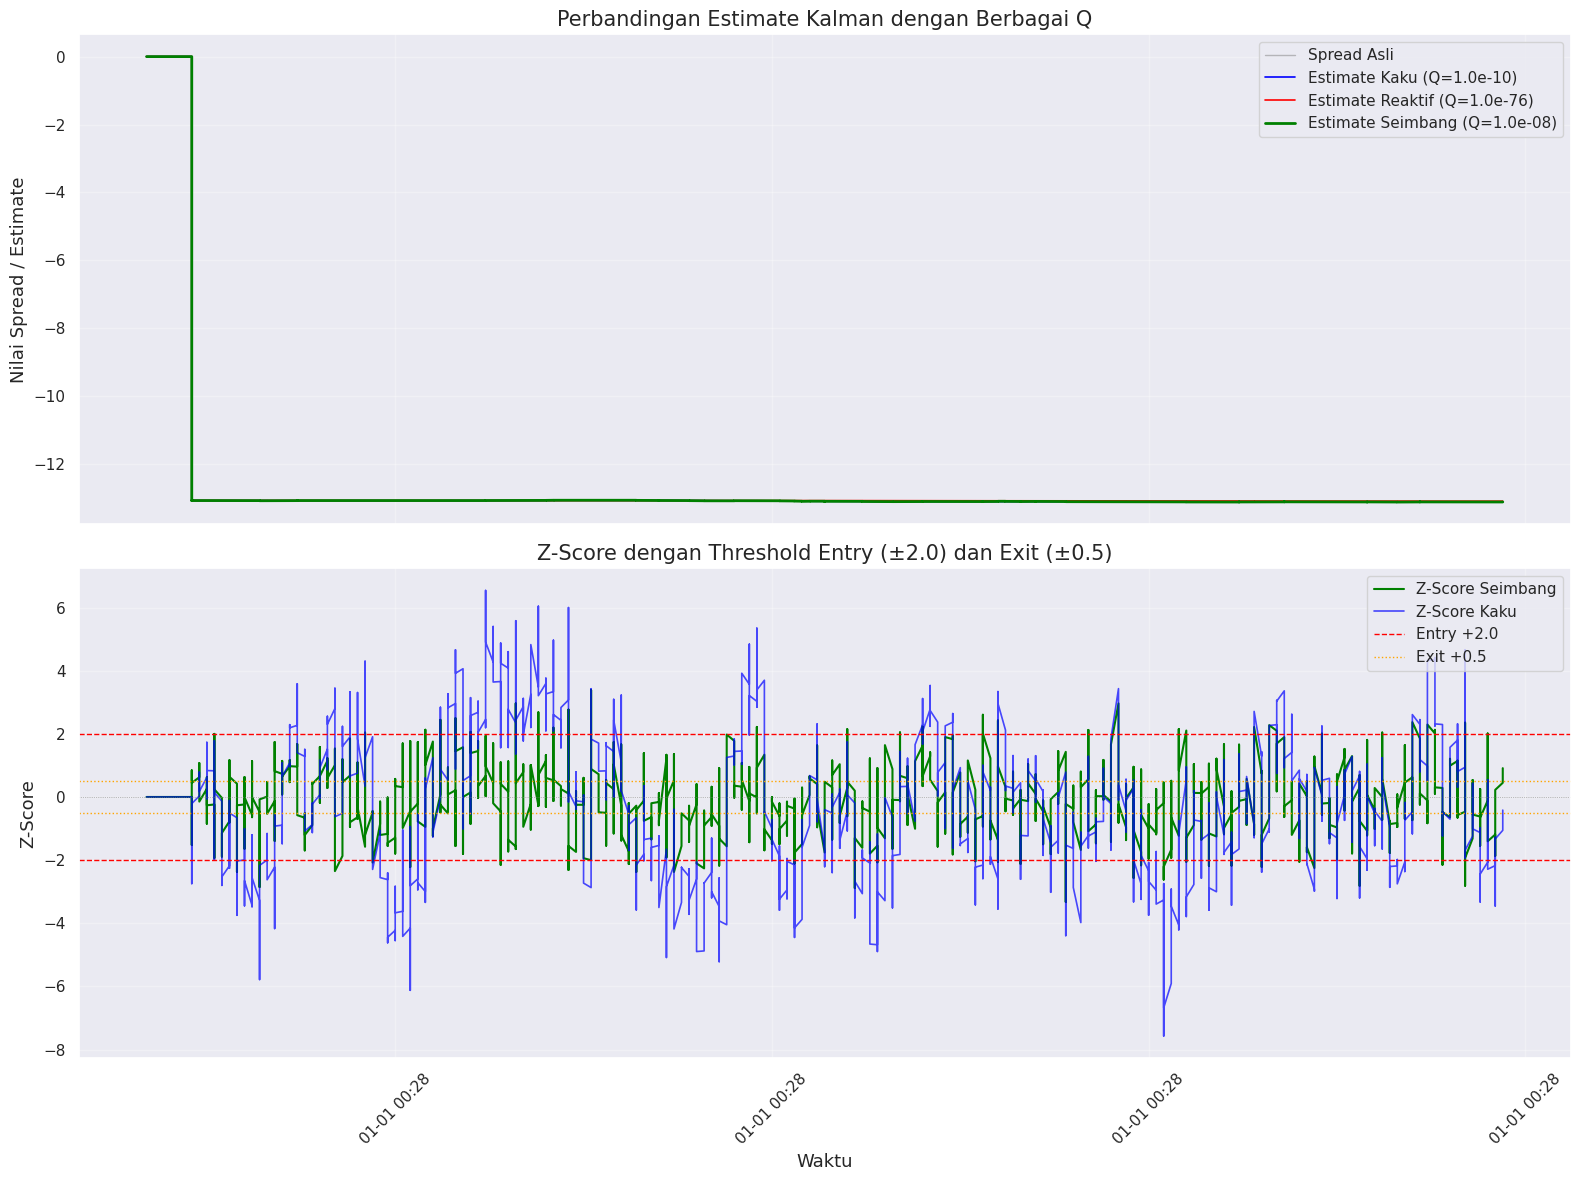


📊 [RINGKASAN SENSITIVITAS Q]

🔹 Skenario Kaku (Q = 1.0e-10)
   Std Dev Z-Score (post-warmup) : 2.1657
   Jumlah BUY       : 1
   Jumlah SELL      : 0
   Jumlah EXIT      : 0
   Jumlah STOP      : 0
   Total sinyal     : 1

🔹 Skenario Seimbang (Q = 1.0e-08)
   Std Dev Z-Score (post-warmup) : 0.9445
   Jumlah BUY       : 0
   Jumlah SELL      : 0
   Jumlah EXIT      : 1
   Jumlah STOP      : 0
   Total sinyal     : 1

🔹 Skenario Reaktif (Q = 1.0e-76)
   Std Dev Z-Score (post-warmup) : 16.9557
   Jumlah BUY       : 1
   Jumlah SELL      : 0
   Jumlah EXIT      : 0
   Jumlah STOP      : 0
   Total sinyal     : 1


In [200]:
# CELL 5: EKSPLORASI SENSITIVITAS Q – VISUAL GRID (REVISI)
# ============================================================================
# Menguji tiga kepribadian Kalman Filter dengan nilai Q berbeda.
# Parameter exit_z diubah menjadi 0.5 agar ada ruang keluar.
# ============================================================================

import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from core.signals.types import SignalConfig
from core.math.kalman import KalmanConfig, AdaptationMode

# ----------------------------------------------------------------------------
# 1. Siapkan data sampel (3000 baris pertama)
# ----------------------------------------------------------------------------
try:
    data_3000 = data_raw.head(3000).with_columns(
        pl.col("timestamp").cast(pl.Int64) // 1_000_000
    )
    print(f"✅ Data sampel: {data_3000.shape[0]} baris (3000 baris pertama).")
except NameError:
    raise NameError("data_raw tidak ditemukan. Jalankan Cell 2 terlebih dahulu.")

# ----------------------------------------------------------------------------
# 2. Parameter tetap
# ----------------------------------------------------------------------------
r_anchor = variance_p50          # dari Cell 3
rolling_window = rolling_window  # dari Cell 3 (60)
entry_z = 2.0
exit_z = 0.5                     # <--- PERUBAHAN: exit_z positif

print(f"🔧 R tetap = {r_anchor:.3e}")
print(f"🔧 Window volatilitas = {rolling_window}")
print(f"🔧 entry_z = {entry_z}, exit_z = {exit_z}")

# ----------------------------------------------------------------------------
# 3. Konfigurasi sinyal (sama untuk semua skenario)
# ----------------------------------------------------------------------------
signal_cfg = SignalConfig(
    name="Sensitivitas_Q_Test",
    entry_z_score=entry_z,
    exit_z_score=exit_z,
    stop_loss_z=4.0,
    max_position=1.0,
    hedge_ratio=1.0,
    volatility_window=rolling_window
)

# ----------------------------------------------------------------------------
# 4. Tiga nilai Q yang akan diuji
# ----------------------------------------------------------------------------
q_values = {
    "kaku": 1e-10,
    "seimbang": 1e-8,
    "reaktif": 1e-76
}

# ----------------------------------------------------------------------------
# 5. Fungsi pembantu untuk menjalankan satu skenario
# ----------------------------------------------------------------------------
def jalankan_skenario(nama: str, q: float) -> pd.DataFrame:
    print(f"\n🚀 Menjalankan skenario: {nama} (Q = {q:.1e})")
    
    math_cfg = KalmanConfig(
        R=r_anchor,
        Q=q,
        initial_value=0.0,
        adaptation_mode=AdaptationMode.NIS_THRESHOLD,
        state_dim=2
    )
    
    mesin = KalmanMeanReversion(
        signal_config=signal_cfg,
        math_config=math_cfg
    )
    
    start = time.time()
    hasil = mesin.generate_signals(data_3000.to_pandas())
    durasi = (time.time() - start) * 1000
    
    if hasil.is_err():
        raise RuntimeError(f"❌ Gagal pada skenario {nama}: {hasil.unwrap_err()}")
    
    df = hasil.unwrap()
    print(f"   ✅ Selesai dalam {durasi:.2f} ms.")
    return df

# ----------------------------------------------------------------------------
# 6. Jalankan ketiga skenario
# ----------------------------------------------------------------------------
df_kaku = jalankan_skenario("kaku", q_values["kaku"])
df_seimbang = jalankan_skenario("seimbang", q_values["seimbang"])
df_reaktif = jalankan_skenario("reaktif", q_values["reaktif"])

# ----------------------------------------------------------------------------
# 7. Tambahkan kolom datetime
# ----------------------------------------------------------------------------
for df in [df_kaku, df_seimbang, df_reaktif]:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# ----------------------------------------------------------------------------
# 8. Visualisasi dua panel
# ----------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Panel Atas: Spread Asli vs Estimate
ax1.plot(df_seimbang['datetime'], df_seimbang['spread_val'],
         color='gray', alpha=0.5, linewidth=1.0, label='Spread Asli')
ax1.plot(df_kaku['datetime'], df_kaku['estimate'],
         color='blue', linewidth=1.2, label=f'Estimate Kaku (Q={q_values["kaku"]:.1e})')
ax1.plot(df_reaktif['datetime'], df_reaktif['estimate'],
         color='red', linewidth=1.2, label=f'Estimate Reaktif (Q={q_values["reaktif"]:.1e})')
ax1.plot(df_seimbang['datetime'], df_seimbang['estimate'],
         color='green', linewidth=2.0, label=f'Estimate Seimbang (Q={q_values["seimbang"]:.1e})')

ax1.set_ylabel('Nilai Spread / Estimate')
ax1.set_title('Perbandingan Estimate Kalman dengan Berbagai Q')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel Bawah: Z-Score
ax2.plot(df_seimbang['datetime'], df_seimbang['z_score'],
         color='green', linewidth=1.5, label='Z-Score Seimbang')
ax2.plot(df_kaku['datetime'], df_kaku['z_score'],
         color='blue', linewidth=1.2, alpha=0.7, label='Z-Score Kaku')

# Garis threshold
ax2.axhline(y=entry_z, color='red', linestyle='--', linewidth=1, label=f'Entry +{entry_z}')
ax2.axhline(y=-entry_z, color='red', linestyle='--', linewidth=1)
ax2.axhline(y=exit_z, color='orange', linestyle=':', linewidth=1, label=f'Exit +{exit_z}')
ax2.axhline(y=-exit_z, color='orange', linestyle=':', linewidth=1)
ax2.axhline(y=0, color='gray', linestyle=':', linewidth=0.5)

ax2.set_xlabel('Waktu')
ax2.set_ylabel('Z-Score')
ax2.set_title('Z-Score dengan Threshold Entry (±2.0) dan Exit (±0.5)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 9. Statistik ringkasan
# ----------------------------------------------------------------------------
print("\n" + "="*60)
print("📊 [RINGKASAN SENSITIVITAS Q]")
print("="*60)

for nama, df in [("Kaku", df_kaku), ("Seimbang", df_seimbang), ("Reaktif", df_reaktif)]:
    z_after = df['z_score'].iloc[100:]
    std_z = z_after.std()
    n_buy = (df['signal_type'] == 'BUY').sum()
    n_sell = (df['signal_type'] == 'SELL').sum()
    n_exit = (df['signal_type'] == 'EXIT').sum()
    n_stop = (df['signal_type'] == 'STOP').sum()
    
    if nama.lower() == "kaku":
        q_val = q_values["kaku"]
    elif nama.lower() == "seimbang":
        q_val = q_values["seimbang"]
    else:
        q_val = q_values["reaktif"]
    
    print(f"\n🔹 Skenario {nama} (Q = {q_val:.1e})")
    print(f"   Std Dev Z-Score (post-warmup) : {std_z:.4f}")
    print(f"   Jumlah BUY       : {n_buy}")
    print(f"   Jumlah SELL      : {n_sell}")
    print(f"   Jumlah EXIT      : {n_exit}")
    print(f"   Jumlah STOP      : {n_stop}")
    print(f"   Total sinyal     : {n_buy + n_sell + n_exit + n_stop}")

print("="*60)